### Imports

In [1]:
import os
import math

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import xgboost
from catboost import CatBoostClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('data/clean/mp_shots_cleaner.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028007 entries, 0 to 1028006
Data columns (total 88 columns):
 #   Column                                                 Non-Null Count    Dtype  
---  ------                                                 --------------    -----  
 0   xcordadjusted                                          1028007 non-null  int64  
 1   shotangle                                              1028007 non-null  float64
 2   defendingteammaxtimeonicesincefaceoff                  1028007 non-null  float64
 3   playerpositionthatdidevent                             1028007 non-null  str    
 4   shootingteammintimeoniceofforwardssincefaceoff         1028007 non-null  float64
 5   defendingteamaveragetimeoniceofdefencemensincefaceoff  1028007 non-null  float64
 6   shotanglereboundroyalroad                              1028007 non-null  int64  
 7   time                                                   1028007 non-null  int64  
 8   shootingteamdefencemenonice      

In [5]:
int_shots = df.select_dtypes('int64').columns
float_shots = df.select_dtypes('float64').columns

df[int_shots] = df[int_shots].apply(pd.to_numeric, downcast='integer')
df[float_shots] = df[float_shots].apply(pd.to_numeric, downcast='float')

obj_shots = df.select_dtypes(include=['object']).columns

for col in obj_shots:
    num_unique = df[col].nunique()
    num_total = len(df[col])

    if num_unique / num_total < 0.5:
        df[col] = df[col].astype('category')

In [6]:
# Find home columns (away columns use same naming conventions)
for col in df.columns:
    if 'home' in col:
        print(col)

homepenalty1length
homeemptynet
homepenalty1timeleft
hometeamgoals
ishometeam
homeskatersonice


In [7]:
# Skaters on ice, removing home/away columns
df = df.drop(columns = ['homeskatersonice', 'awayskatersonice'], errors='ignore')
df['shootingteamplayersonice'] = df['shootingteamdefencemenonice'] + df['shootingteamforwardsonice']
df['defendingteamplayersonice'] = df['defendingteamdefencemenonice'] + df['defendingteamforwardsonice']

In [8]:
# Dropping goal count and home/away empty net
df = df.drop(columns= ['hometeamgoals', 'awayteamgoals', 'awayemptynet', 'homeemptynet'], errors='ignore')

In [9]:
# Fix home/away penalty stats
df['powerplaylength'] = np.where((df['ishometeam']==1), df['homepenalty1length'], df['awaypenalty1length'])
df['penaltykilllength'] = np.where((df['ishometeam']==1), df['awaypenalty1length'], df['homepenalty1length'])
df['powerplaytimeleft'] = np.where((df['ishometeam']==1), df['homepenalty1timeleft'], df['awaypenalty1timeleft'])
df['penaltykilltimeleft'] = np.where((df['ishometeam']==1), df['awaypenalty1timeleft'], df['homepenalty1timeleft'])

In [10]:
# Drop home/away penalty stats
df = df.drop(columns = ['homepenalty1length', 'awaypenalty1length', 'homepenalty1timeleft', 'awaypenalty1timeleft'], errors='ignore')

In [11]:
# Recheck
for col in df.columns:
    if 'away' in col:
        print(col)

In [12]:
# Drop non relative and redundant measurements
df = df.drop(columns = ['xcord', 'ycord', 'shotangle', 'shotangleadjusted', 'shotdistance',
                        'lasteventxcord', 'lasteventycord', 'lasteventshotangle', 'location'],
             errors='ignore'
            )

In [13]:
# Fix lasteventteam values
df = df[df['lasteventteam'].isin(['HOME', 'AWAY'])]
df.loc[:, 'lasteventhometeam'] = df['lasteventteam'] == 'HOME'
df = df.drop(columns=['lasteventteam'], errors='ignore')
df['lasteventhometeam'] = df['lasteventhometeam'].astype('int8')

In [14]:
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['playerpositionthatdidevent', 'shottype', 'lasteventcategory'], dtype='str')

In [15]:
# Fix lasteventcategory values
for col in cat_cols:
    df[col] = df[col].astype('string')
    vc = df[col].value_counts()
    rare = vc[vc < 100].index
    df[col] = df[col].replace(rare, 'OTHER')

In [16]:
# Drop shotwasongoal
#   After an initial round of testing, shotwasongoal was by far the most important feature, and I realized that it is dependent on the outcome of the shot and a source of data leakage
df = df.drop(columns='shotwasongoal', errors='ignore')

### Train-test split

In [17]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [18]:
X = df.drop('goal', axis=1)
y= df['goal'].copy()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=12)

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((719472, 73), (308346, 73), (719472,), (308346,))

In [21]:
# Scaling
scale_cols = [
    'xcordadjusted', 'time', 'lasteventshotdistance', 'averagerestdifference', 'lasteventxcord_adjusted',
    'lasteventycord_adjusted', 'timedifferencesincechange', 'timesincelastevent', 'timesincefaceoff',
    'shotangleplusrebound', 'distancefromlastevent', 'speedfromlastevent', 'ycordadjusted',
    'shotangleplusreboundspeed', 'powerplaylength', 'penaltykilllength', 'powerplaytimeleft', 'penaltykilltimeleft',
    # TOI Features
    *(c for c in X.columns if 'timeonice' in c)
]
scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [22]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

In [23]:
# Get Dummies
cat_cols = X_train_scaled.select_dtypes(exclude=np.number).columns
cat_cols

Index(['playerpositionthatdidevent', 'shottype', 'lasteventcategory'], dtype='str')

In [24]:
X_train_scaled_encoded = pd.get_dummies(X_train_scaled, columns=cat_cols, drop_first=True)
X_test_scaled_encoded = pd.get_dummies(X_test_scaled, columns=cat_cols, drop_first=True)
X_test_scaled_encoded = X_test_scaled_encoded.reindex(columns=X_train_scaled_encoded.columns, fill_value=0)
assert list(X_train_scaled_encoded.columns) == list(X_test_scaled_encoded.columns)

In [25]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
assert list(X_train_encoded.columns) == list(X_test_encoded.columns)

In [26]:
#del X_train, X_test, X_train_scaled, X_test_scaled
#import gc; gc.collect()

# Models

In [27]:
# Imports
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from joblib import load, dump

In [28]:
print(xgb.__version__)
print(xgb.build_info())

3.2.0
{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\chris\\AppData\\Local\\Python\\pythoncore-3.13-64\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'}


### Parameter grids

In [29]:
lr_param_grid = {
    'C': [0.1, 1, 10],
    'l1_ratio': [0,1]
}

XGB_param_grid = {
    'n_estimators':[600, 1000, 1600],
   'learning_rate':[0.02, 0.05, 0.1],
   'max_depth':[3, 6, 9],
   'subsample':[0.5, 0.9],
   'min_child_weight':[1, 5, 10]
}

RF_param_grid = {
    'n_estimators':[50, 100, 200],
    'max_depth':[3, 6, 9],
    'min_samples_leaf':[1,5,10]
}

In [30]:
# Logistic Regression
logreg_search = GridSearchCV(
    LogisticRegression(
        solver='saga',
        max_iter=400,
        class_weight='balanced',
        random_state=12),
    lr_param_grid,
    n_jobs=-2,
    verbose=0,
    scoring='average_precision')

# XGBoost
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
xgboost_search = RandomizedSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=(num_neg / num_pos),
        tree_method='hist',
        device='cuda',
        random_state=12),
    XGB_param_grid,
    verbose=0,
    n_jobs=1,
    error_score='raise',
    scoring='average_precision')

# Random Forest
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        criterion='gini',
        class_weight='balanced_subsample',
        random_state=12
        ),
    RF_param_grid,
    n_jobs=-2,
    verbose=0,
    scoring='average_precision')


In [31]:
results = []

### Logistic Regression

In [32]:
if os.path.exists('logreg_search.joblib'):
    logreg_search = load('logreg_search.joblib')
else:
    logreg_search.fit(X_train_scaled_encoded, y_train)
    dump(logreg_search, 'logreg_search.joblib')

In [33]:
logreg_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'l1_ratio': [0, 1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

In [34]:
best_idx = logreg_search.best_index_
best_model = logreg_search.best_estimator_
logreg_test_pred = best_model.predict(X_test_scaled_encoded)
logreg_holdout_ap = average_precision_score(y_test, logreg_test_pred)

results.append({
    'model': 'LogisticRegression',
    'cv_mean': logreg_search.best_score_,
    'cv_std': logreg_search.cv_results_['std_test_score'][best_idx],
    'best_params': logreg_search.best_params_,
    'holdout_ap': logreg_holdout_ap
})


In [35]:
print(
    f'LogisticRegression '
    f'CV mean: {logreg_search.best_score_:.4f} | '
    f'CV std: {logreg_search.cv_results_['std_test_score'][best_idx]:.4f} | '
    f'holdout AP: {logreg_holdout_ap:.4f}'
)
print(results)


LogisticRegression CV mean: 0.2193 | CV std: 0.0031 | holdout AP: 0.1074
[{'model': 'LogisticRegression', 'cv_mean': np.float64(0.2192843409944106), 'cv_std': np.float64(0.0031327155394738123), 'best_params': {'C': 1, 'l1_ratio': 1}, 'holdout_ap': 0.10743764247740811}]


In [36]:
logreg_importances = pd.Series(best_model.coef_.ravel(),index=X_train_scaled_encoded.columns).sort_values(key=lambda s: s.abs(), ascending=False)
logreg_importances.head(20)

shotonemptynet                               5.356349
lasteventcategory_OTHER                      2.632667
playerpositionthatdidevent_OTHER            -1.943634
defendingteamplayersonice                   -0.920035
shotrebound                                  0.720097
xcordadjusted                                0.710993
shottype_WRAP                               -0.648256
shotrush                                     0.605724
shottype_SNAP                                0.560467
shottype_SLAP                                0.559104
penaltykilllength                           -0.463503
shotanglereboundroyalroad                    0.447533
lasteventcategory_PENL                       0.446304
defendingteamaveragetimeonicesincefaceoff    0.327796
shottype_DEFL                                0.320520
shootingteamaveragetimeonicesincefaceoff     0.295667
shottype_TIP                                 0.273055
shootingteamplayersonice                     0.264697
lasteventcategory_DELPEN    

In [37]:
del logreg_search
import gc; gc.collect()

38

### XGBoost

In [38]:
if os.path.exists('xgboost_search.joblib'):
    xgboost_search = load('xgboost_search.joblib')
else:
    xgboost_search.fit(X_train_encoded, y_train)
    dump(xgboost_search, 'xgboost_search.joblib')

In [39]:
best_idx = xgboost_search.best_index_
best_model = xgboost_search.best_estimator_
xgb_test_pred = best_model.predict(X_test_encoded)
xgb_holdout_ap = average_precision_score(y_test, xgb_test_pred)

results.append({
    'model': 'XGBClassifier',
    'cv_mean': xgboost_search.best_score_,
    'cv_std': xgboost_search.cv_results_['std_test_score'][best_idx],
    'best_params': xgboost_search.best_params_,
    'holdout_ap': xgb_holdout_ap
})


In [40]:
print(
    f'XGBoostClassifier '
    f'CV mean: {xgboost_search.best_score_:.4f} | '
    f'CV std: {xgboost_search.cv_results_['std_test_score'][best_idx]:.4f} | '
    f'best_params: {xgboost_search.best_params_} | '
    f'holdout AP: {xgb_holdout_ap:.4f}'
)


XGBoostClassifier CV mean: 0.3665 | CV std: 0.0039 | best_params: {'subsample': 0.5, 'n_estimators': 600, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.05} | holdout AP: 0.1397


In [41]:
xgb_importances = pd.Series(best_model.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
xgb_importances.head(20)


shotonemptynet                          0.118925
defendingteamplayersonice               0.047144
ishometeam                              0.046948
penaltykilllength                       0.040902
powerplaylength                         0.040787
penaltykilltimeleft                     0.035819
shootingteamplayersonice                0.031774
xcordadjusted                           0.031767
shootingteamforwardsonice               0.026314
shotanglereboundroyalroad               0.026208
shotrebound                             0.024702
ycordadjusted                           0.022380
shootingteamdefencemenonice             0.019537
shottype_WRAP                           0.018664
shottype_SNAP                           0.018473
shottype_TIP                            0.016890
period                                  0.015721
shootingteammintimeonicesincefaceoff    0.013795
shottype_WRIST                          0.013573
shottype_SLAP                           0.013393
dtype: float32

In [42]:
results

[{'model': 'LogisticRegression',
  'cv_mean': np.float64(0.2192843409944106),
  'cv_std': np.float64(0.0031327155394738123),
  'best_params': {'C': 1, 'l1_ratio': 1},
  'holdout_ap': 0.10743764247740811},
 {'model': 'XGBClassifier',
  'cv_mean': np.float64(0.36645042365768576),
  'cv_std': np.float64(0.003934192522476329),
  'best_params': {'subsample': 0.5,
   'n_estimators': 600,
   'min_child_weight': 10,
   'max_depth': 6,
   'learning_rate': 0.05},
  'holdout_ap': 0.13967191524129427}]

In [43]:
del xgboost_search
import gc; gc.collect()

18

### Random Forest

In [44]:
# random forest
if os.path.exists('rf_search.joblib'):
    rf_search = load('rf_search.joblib')
else:
    rf_search.fit(X_train_encoded, y_train)
    dump(rf_search, 'rf_search.joblib')
best_idx = rf_search.best_index_

best_model = rf_search.best_estimator_
rf_test_pred = best_model.predict(X_test_encoded)
rf_holdout_ap = average_precision_score(y_test, rf_test_pred)

results.append({
    'model': 'RandomForestClassifier',
    'cv_mean': rf_search.best_score_,
    'cv_std': rf_search.cv_results_['std_test_score'][best_idx],
    'best_params': rf_search.best_params_,
    'holdout_ap': rf_holdout_ap
})


In [45]:
print(
    f'RandomForestClassifier '
    f'CV mean: {rf_search.best_score_:.4f} | '
    f'CV std: {rf_search.cv_results_['std_test_score'][best_idx]:.4f} | '
    f'best_params: {rf_search.best_params_} | '
    f'holdout AP: {rf_holdout_ap:.4f}'
)


RandomForestClassifier CV mean: 0.2578 | CV std: 0.0017 | best_params: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 9} | holdout AP: 0.1166


In [46]:
results

[{'model': 'LogisticRegression',
  'cv_mean': np.float64(0.2192843409944106),
  'cv_std': np.float64(0.0031327155394738123),
  'best_params': {'C': 1, 'l1_ratio': 1},
  'holdout_ap': 0.10743764247740811},
 {'model': 'XGBClassifier',
  'cv_mean': np.float64(0.36645042365768576),
  'cv_std': np.float64(0.003934192522476329),
  'best_params': {'subsample': 0.5,
   'n_estimators': 600,
   'min_child_weight': 10,
   'max_depth': 6,
   'learning_rate': 0.05},
  'holdout_ap': 0.13967191524129427},
 {'model': 'RandomForestClassifier',
  'cv_mean': np.float64(0.2577881626899224),
  'cv_std': np.float64(0.0017227694855593643),
  'best_params': {'n_estimators': 100, 'min_samples_leaf': 5, 'max_depth': 9},
  'holdout_ap': 0.11663883962560126}]

In [47]:
del rf_search
import gc; gc.collect()

0

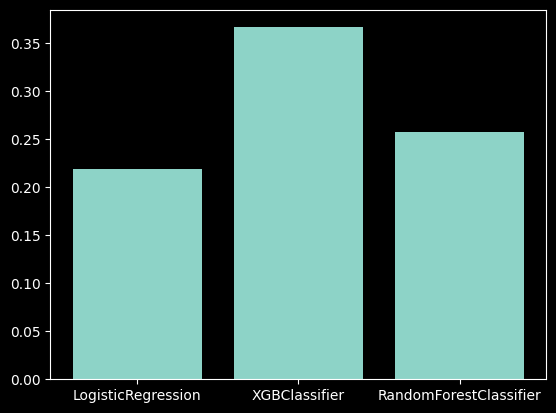

In [48]:
results_df = pd.DataFrame(results)
plt.bar(results_df['model'], results_df['cv_mean'])
plt.show()

Based on these results, the XGBClassifier performed best with an average area under the precision recall curve (PR-AUC) of 0.37. However, the number of false positives is far too high for my liking. I think I need to figure out how to tune this so that the number of predicted goals is roughly the same as the number of actual goals.

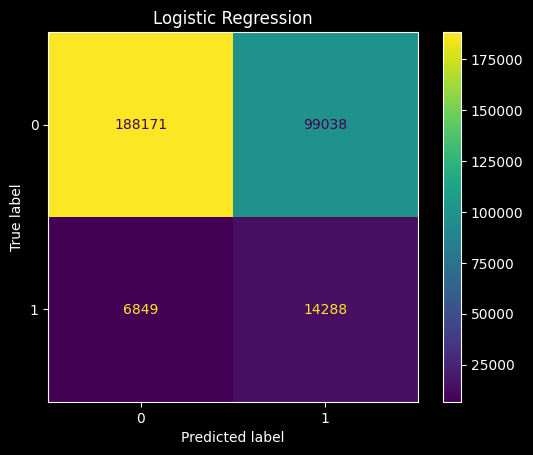

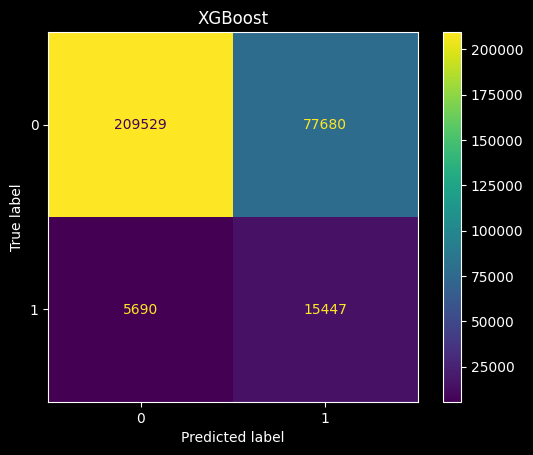

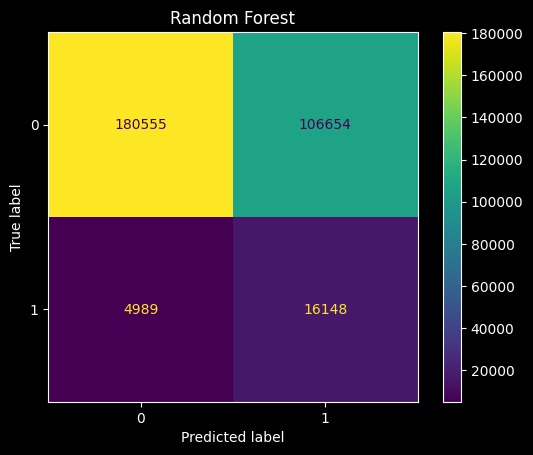

In [49]:
predictions = {
    'Logistic Regression': logreg_test_pred,
    'XGBoost': xgb_test_pred,
    'Random Forest': rf_test_pred
}
for model, prediction in predictions.items():
    cfm = confusion_matrix(y_test, prediction)
    disp = ConfusionMatrixDisplay(cfm)
    disp.plot()
    plt.title(model)

In [50]:
cfm = confusion_matrix(y_test, xgb_test_pred, labels=[0, 1])
print(y_test.sum()/len(y_test))
print(cfm)


0.0685496163400855
[[209529  77680]
 [  5690  15447]]


## Boosting Models

In [51]:
import lightgbm as lgb
import ipywidgets
import catboost
from catboost import CatBoostClassifier
import time
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, roc_curve, auc, log_loss


#### Over and Undersampling in LightGBM

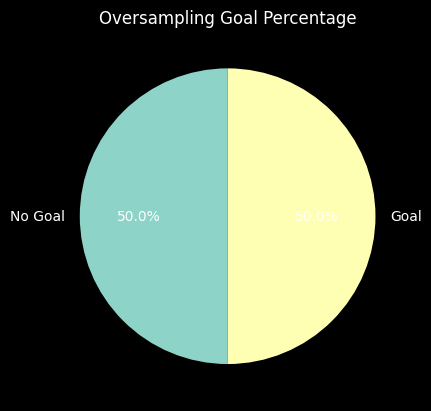

(1340302, 89)


In [52]:
# Testing oversampling
ros = RandomOverSampler(random_state=12)
X_ros, y_ros = ros.fit_resample(X_train_encoded, y_train)
pd.Series(y_ros).value_counts().plot.pie(autopct='%1.1f%%', startangle=90, title='Oversampling Goal Percentage', labels=['No Goal', 'Goal'])
plt.show()
print(X_ros.shape)

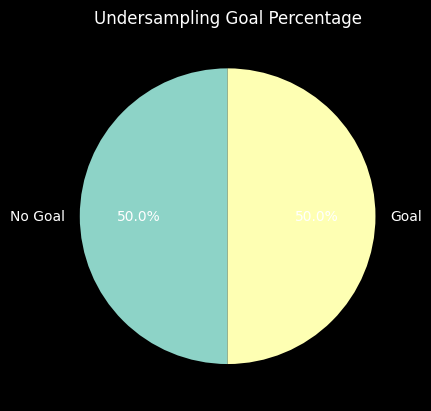

(98642, 89)


In [53]:
rus = RandomUnderSampler(random_state=12)
X_rus, y_rus = rus.fit_resample(X_train_encoded, y_train)
pd.Series(y_rus).value_counts().plot.pie(autopct='%1.1f%%', startangle=90, title='Undersampling Goal Percentage', labels=['No Goal', 'Goal'])
plt.show()
print(X_rus.shape)

In [54]:
def lgbm_search(X, y):
    """
    Grid search with varying learning rate and n_estimators for LightGBM.
    Primarily to identify whether oversampling is worthwhile.
    Outputs a dictionary with the best estimator, score, and parameters for a given X/Y pairing.
    """
    # Parameter Grid
    lgbm_param_grid = {
        'learning_rate':[0.001, 0.01, 0.1],
        'n_estimators':[100, 800, 1000]
    }

    # Model
    num_pos = (y == 1).sum()
    num_neg = (y == 0).sum()
    light_gbm = lgb.LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        scale_pos_weight=num_neg/num_pos
    )

    # Grid Search
    gs = GridSearchCV(
        light_gbm,
        param_grid=lgbm_param_grid,
        cv=5,
        n_jobs=-1,
        scoring='average_precision',
        verbose=3
    )
    # Model
    start = time.time()
    gs.fit(X, y)
    gs_train_time = time.time() - start
    # Output
    output = {
        'best_estimator':gs.best_estimator_,
        'best_score':gs.best_score_,
        'best_params':gs.best_params_,
        'train_time':gs_train_time,
    }
    return output

In [55]:
# Call lgbm_search
if os.path.exists('lgbm_os.joblib'):
    lgbm_os = load('lgbm_os.joblib')
    lgbm_us = load('lgbm_us.joblib')
    lgbm_ns = load('lgbm_ns.joblib')
else:
    lgbm_os = lgbm_search(X_ros, y_ros)
    lgbm_ns = lgbm_search(X_train_encoded, y_train)
    lgbm_us = lgbm_search(X_rus, y_rus)
    dump(lgbm_os, 'lgbm_os.joblib')
    dump(lgbm_us, 'lgbm_us.joblib')
    dump(lgbm_ns, 'lgbm_ns.joblib')


In [56]:
def sample_comparison(os, ns, us):
    """
    os: oversampling results (from lgbm_search)
    ns: non oversampling results (from lgbm_search)
    us: unoversampling results (from lgbm_search)

    returns plots that compare oversampled, undersampled, and normally sampled datasets,
    including a f1/precision/recall, confusion matrix, and ROC Curves.
    """
    fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))

    # ---- predictions ----
    pred_ns = ns['best_estimator'].predict(X_test_encoded)
    pred_os = os['best_estimator'].predict(X_test_encoded)
    pred_us = us['best_estimator'].predict(X_test_encoded)
    prob_ns = ns['best_estimator'].predict_proba(X_test_encoded)[:, 1]
    prob_os = os['best_estimator'].predict_proba(X_test_encoded)[:, 1]
    prob_us = us['best_estimator'].predict_proba(X_test_encoded)[:, 1]

    # ---- metrics ----
    metrics = {
        'NS': {
            'precision': precision_score(y_test, pred_ns, zero_division=0),
            'recall': recall_score(y_test, pred_ns, zero_division=0),
            'f1': f1_score(y_test, pred_ns, zero_division=0),
            'log_loss': log_loss(y_test, prob_ns),
        },
        'OS': {
            'precision': precision_score(y_test, pred_os, zero_division=0),
            'recall': recall_score(y_test, pred_os, zero_division=0),
            'f1': f1_score(y_test, pred_os, zero_division=0),
            'log_loss': log_loss(y_test, prob_os),
        },
        'US': {
            'precision': precision_score(y_test, pred_us, zero_division=0),
            'recall': recall_score(y_test, pred_us, zero_division=0),
            'f1': f1_score(y_test, pred_us, zero_division=0),
            'log_loss': log_loss(y_test, prob_us),
        }
    }

    # ---- (0,0) CV AP bar ----
    labels = ['Normally Sampled', 'Oversampled', 'Undersampled']
    scores = [ns['best_score'], os['best_score'], us['best_score']]

    bars = ax[0, 0].bar(labels, scores)
    ax[0, 0].set_title('Best CV Average Precision')
    ax[0, 0].set_ylabel('AP')
    # annotate exact values
    for bar, score in zip(bars, scores):
        ax[0, 0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{score:.4f}',
            ha='center',
            va='bottom'
        )


    # ---- (0,1) metrics text ----
    ax[0, 1].axis('off')
    ax[0, 1].text(
        0.05, 0.95,
        'Normally Sampled\n'
        f'Log Loss:  {metrics['NS']['log_loss']:.3f}\n'
        f'Precision: {metrics['NS']['precision']:.3f}\n'
        f'Recall:    {metrics['NS']['recall']:.3f}\n'
        f'F1:        {metrics['NS']['f1']:.3f}\n\n'
        'Oversampled\n'
        f'Log Loss:  {metrics['OS']['log_loss']:.3f}\n'
        f'Precision: {metrics['OS']['precision']:.3f}\n'
        f'Recall:    {metrics['OS']['recall']:.3f}\n'
        f'F1:        {metrics['OS']['f1']:.3f}\n\n'
        'Undersampled\n'
        f'Log Loss:  {metrics['US']['log_loss']:.3f}\n'
        f'Precision: {metrics['US']['precision']:.3f}\n'
        f'Recall:    {metrics['US']['recall']:.3f}\n'
        f'F1:        {metrics['US']['f1']:.3f}\n',
        transform=ax[0, 1].transAxes,
        verticalalignment='top',
        fontfamily='monospace',
    )
    # ---- (0,2) train time ----
    times = [ns['train_time'], os['train_time'], us['train_time']]
    ax[0, 2].bar(labels, times)
    ax[0, 2].set_title('Train Time')
    ax[0, 2].set_ylabel('Seconds')

    # ---- (1,0) confusion matrix NS ----
    cm_ns = confusion_matrix(y_test, pred_ns)
    ConfusionMatrixDisplay(cm_ns).plot(ax=ax[1, 0], cmap='Purples', colorbar=False, values_format='d')
    ax[1, 0].set_title('Confusion Matrix – Normally Sampled')

    # ---- (1,1) confusion matrix OS ----
    cm_os = confusion_matrix(y_test, pred_os)
    ConfusionMatrixDisplay(cm_os).plot(ax=ax[1, 1], cmap='Purples', colorbar=False, values_format='d')
    ax[1, 1].set_title('Confusion Matrix – Oversampled')

    # ---- (1,2) confusion matrix US ----
    cm_us = confusion_matrix(y_test, pred_us)
    ConfusionMatrixDisplay(cm_us).plot(ax=ax[1, 2], cmap='Purples', colorbar=False, values_format='d')
    ax[1,2].set_title('Confusion Matrix - Undersampled')

    # ---- (2,0) ROC NS ----
    fpr, tpr, thresholds = roc_curve(y_test, prob_ns)
    roc_auc = auc(fpr, tpr)
    ax[2,0].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax[2,0].legend(loc='lower right')
    ax[2,0].set_title('ROC Curve - Normally Sampled')

    # ---- (2,1) ROC OS ----
    fpr, tpr, thresholds = roc_curve(y_test, prob_os)
    roc_auc = auc(fpr, tpr)
    ax[2,1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax[2,1].legend(loc='lower right')
    ax[2,1].set_title('ROC Curve - Oversampled')

    # ---- (2,2) ROC US ----
    fpr, tpr, thresholds = roc_curve(y_test, prob_us)
    roc_auc = auc(fpr, tpr)
    ax[2,2].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax[2,2].legend(loc='lower right')
    ax[2,2].set_title('ROC Curve - Undersampled')

    plt.tight_layout()
    return fig, ax

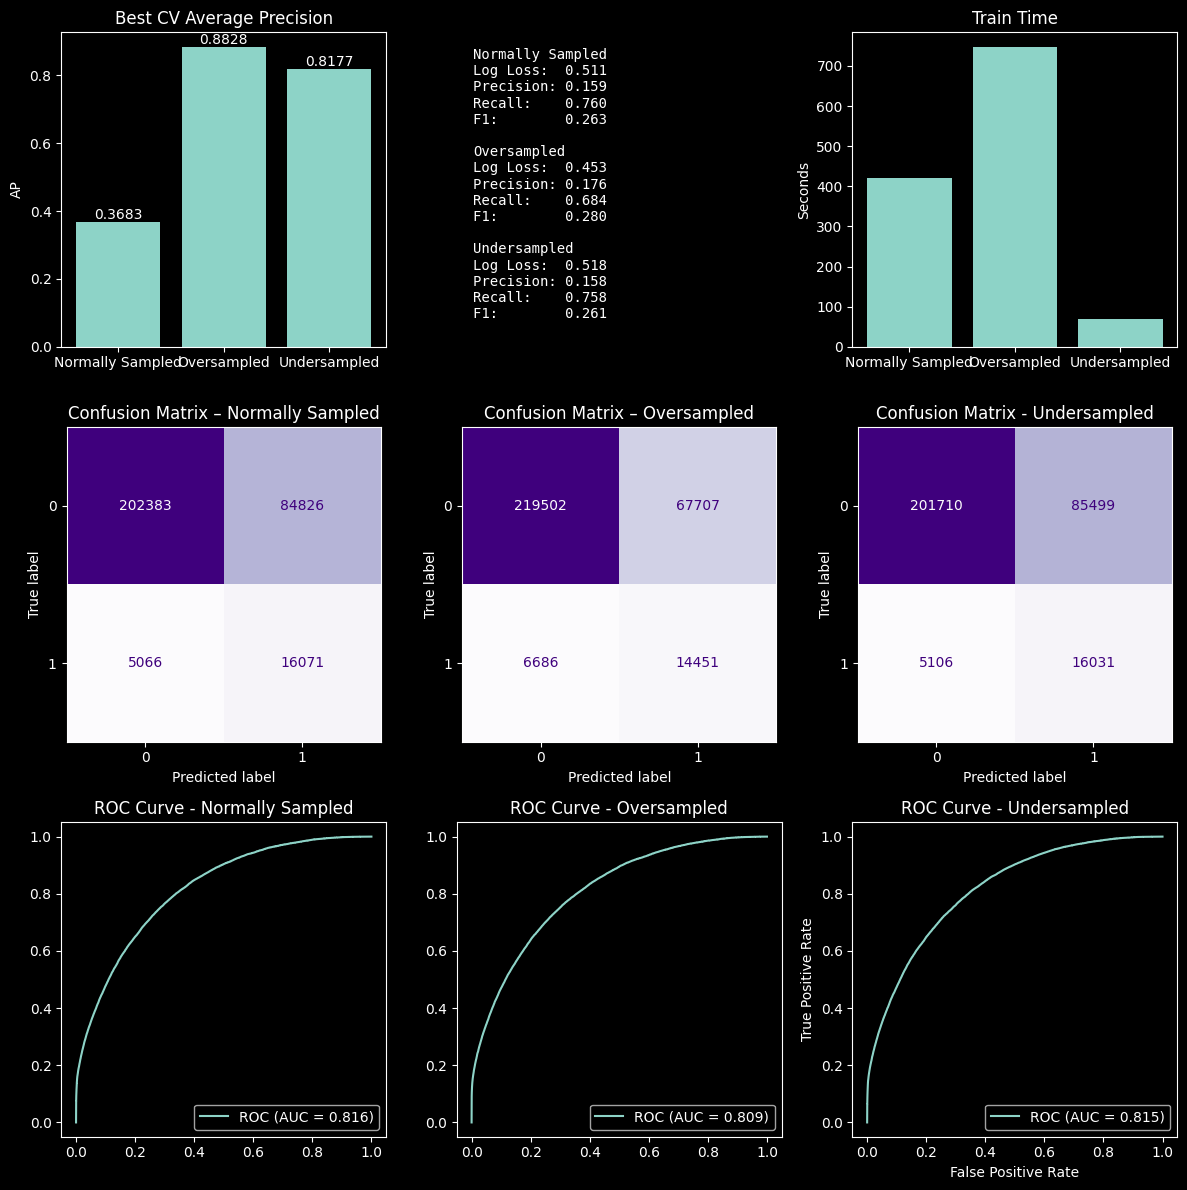

In [57]:
sample_comparison(lgbm_os, lgbm_ns, lgbm_us)

plt.show()

Oversampling performed better than undersampling when looking at CV Average Precision (normal skewed by imbalanced dataset),
and outperformed both regular sampling and undersampling in log loss and F1 scoring. Undersampling decreased the AUC slightly, but to a lesser degree.
For model selection and hyperparameter tuning, I'll continue with the undersampled data to reduce processing time, as the undersampled data took significantly less time to fit.

In [58]:
# Pred/prob for regular sampling
lgbm_ns_pred = lgbm_ns['best_estimator'].predict(X_test_encoded)
lgbm_ns_prob = lgbm_ns['best_estimator'].predict_proba(X_test_encoded)[:, 1]
# Pred/prob for oversampling
lgbm_os_pred = lgbm_os['best_estimator'].predict(X_test_encoded)
lgbm_os_prob = lgbm_os['best_estimator'].predict_proba(X_test_encoded)[:, 1]

In [59]:
# Pred/prob for undersampling
lgbm_us_pred = lgbm_us['best_estimator'].predict(X_test_encoded)
lgbm_us_prob = lgbm_us['best_estimator'].predict_proba(X_test_encoded)[:, 1]

In [60]:
# Identifying the most important features
best_model = lgbm_us['best_estimator']
lgbm_importances = pd.Series(best_model.feature_importances_, index=X_rus.columns).sort_values(ascending=False)
top_30 = lgbm_importances.index[:30] # 30 features that are the most important for the model (lgbm, normal sampling)

In [61]:
imp_norm = lgbm_importances / lgbm_importances.sum()

feat_imp = (
    pd.DataFrame({
        'feature': lgbm_importances.index,
        'importance': imp_norm
    })
    .sort_values('importance', ascending=False)
)
feat_imp

,feature,importance
ycordadjusted,ycordadjusted,0.102233
xcordadjusted,xcordadjusted,0.083167
ishometeam,ishometeam,0.045133
timesincelastevent,timesincelastevent,0.043833
speedfromlastevent,speedfromlastevent,0.027167
...,...,...
lasteventcategory_FAC,lasteventcategory_FAC,0.000333
lasteventcategory_TAKE,lasteventcategory_TAKE,0.000167
playerpositionthatdidevent_OTHER,playerpositionthatdidevent_OTHER,0.000000
lasteventcategory_PENL,lasteventcategory_PENL,0.000000


In [62]:
# New X train and test using the selected features
X_train_sel = X_rus[top_30]
X_test_sel = X_test_encoded[top_30]

In [63]:
# Rerunning fit to check for change in performance
if os.path.exists('lgbm_sel.joblib'):
    lgbm_sel = load('lgbm_sel.joblib')
else:
    lgbm_sel = lgbm_search(X_train_sel, y_rus)
    dump(lgbm_sel, 'lgbm_sel.joblib')

In [64]:
sel_pred = lgbm_sel['best_estimator'].predict(X_test_sel)
sel_proba = lgbm_sel['best_estimator'].predict_proba(X_test_sel)[:, 1]

In [65]:
print(lgbm_sel['best_score'], lgbm_us['best_score']) # Comparison of average precision (PR-AUC)

0.8169455949539888 0.8176815386880513


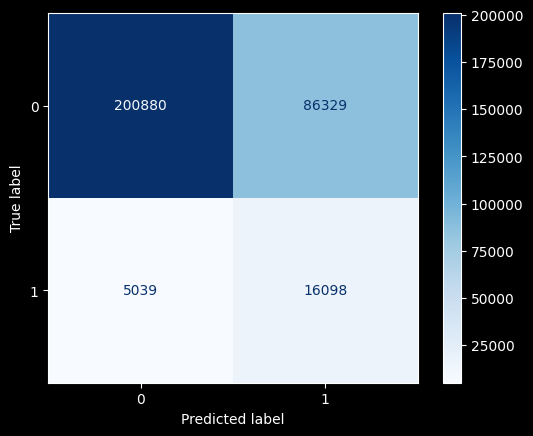

In [66]:
cfm = confusion_matrix(y_test, sel_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

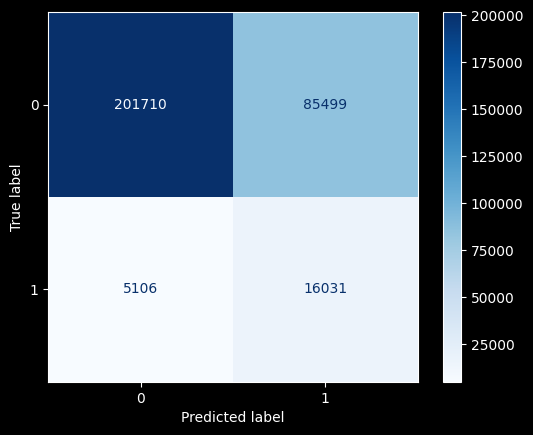

In [67]:
cfm = confusion_matrix(y_test, lgbm_us_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

#### Light GBM

In [68]:
# Setup model and parameters
light_model  = lgb.LGBMClassifier(n_estimators=800, verbose=-1, random_state=12, metric='binary_logloss')
lgbm_param_grid = {
    'learning_rate':[0.01, 0.05, 0.1],
    'min_data_in_leaf':[10, 20, 100],
    'num_leaves':[64, 128, 256]
}

In [69]:
# Run Grid Search/fit
if os.path.exists('light_search.joblib'):
    light_search = load('light_search.joblib')
else:
    light_search = GridSearchCV(light_model, lgbm_param_grid,  cv=5, scoring='neg_log_loss', verbose=0)
    light_search.fit(X_train_sel, y_rus)
    dump(light_search, 'light_search.joblib')

In [70]:
# Predict/predict proba, print best score
light_pred = light_search.predict(X_test_sel)
light_proba = light_search.predict_proba(X_test_sel)[:, 1]
light_search.best_score_

np.float64(-0.5178981104174256)

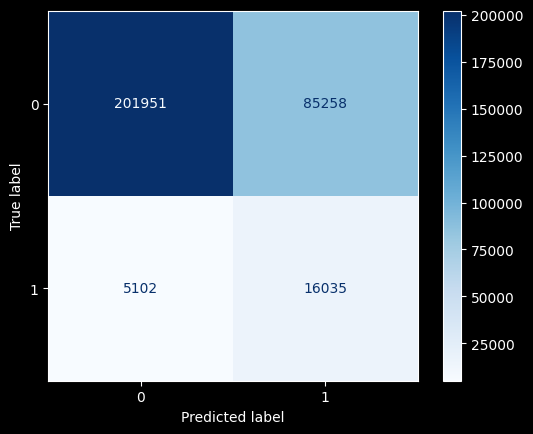

In [71]:
# Confusion Matrix
cfm = confusion_matrix(y_test, light_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

#### XG Boost

In [72]:
# Setup XGB Model
xgb_model  = xgb.XGBClassifier(n_estimators=1000, random_state=12, tree_method='hist', n_jobs=-1, device='cuda', verbosity=0)
xgboost_param_grid = {
    'eta':[0.01, 0.05, 0.1],
    'max_depth':[3, 5, 7, 9],
    'min_child_weight':[1, 3, 5, 10, 20]
}

In [73]:
# Run/fit/save search
if os.path.exists('xgb_search.joblib'):
    xgb_search = load('xgb_search.joblib')
else:
    xgb_search = GridSearchCV(xgb_model, xgboost_param_grid, cv=5, scoring='neg-log-loss')
    xgb_search.fit(X_train_sel, y_rus)
    dump(xgb_search, 'xgb_search.joblib')


In [74]:
# Predict/predict proba
xgb_pred = xgb_search.predict(X_test_sel)
xgb_proba = xgb_search.predict_proba(X_test_sel)[:, 1]
xgb_search.best_score_

np.float64(-0.5182160418889772)

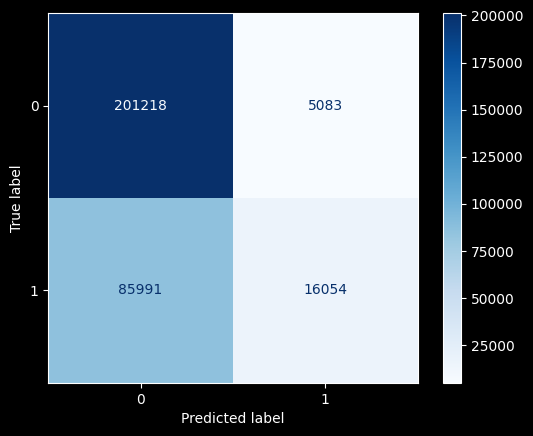

In [75]:
# Confusion matrix
cfm = confusion_matrix(xgb_pred, y_test)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

#### Catboost

Because catboost is able to work with unencoded features, I'm returning to the original X and Y train

In [76]:
# ID categorical columns
cat_cols = X_train_scaled.select_dtypes(exclude=['number', 'bool']).columns.tolist()
cat_cols

['playerpositionthatdidevent', 'shottype', 'lasteventcategory']

In [77]:
# Undersample original X_train for catboost
rus = RandomUnderSampler(random_state=12)
X_cat, y_cat = rus.fit_resample(X_train, y_train)

In [78]:
# Setup model/parameters
cat_indices = [X_cat.columns.get_loc(c) for c in cat_cols]
cat_model = CatBoostClassifier(cat_features = cat_indices, random_seed=12, verbose=0, eval_metric="Logloss")

cat_param_grid = {
    'learning_rate':[0.01, 0.03, 0.05],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [2, 4, 6, 8, 10],
}

In [79]:
# Run Search
if os.path.exists('cat_search.joblib'):
    cat_search = load('cat_search.joblib')
else:
    cat_search = cat_model.grid_search(param_grid=cat_param_grid, cv=5, X=X_cat, y=y_cat, partition_random_seed=12)
    dump(cat_search, 'cat_search.joblib')

In [80]:
# View CV results
cat_cv_df = pd.DataFrame(cat_search['cv_results'])
cat_cv_df.sort_values('test-Logloss-mean', ascending=True).head()

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std
984,984,0.516561,0.002628,0.465881,0.001021
998,998,0.516562,0.002617,0.465112,0.001024
983,983,0.516563,0.002631,0.465947,0.001037
999,999,0.516565,0.002611,0.465055,0.001025
985,985,0.516566,0.002621,0.465825,0.001020


In [81]:
# Fit/save model with best params
if os.path.exists('catboost_model.cbm'):
    cat_model = CatBoostClassifier()
    cat_model.load_model("catboost_model.cbm")
else:
    best_params = cat_search['params'] # Retrieve the best parameters from grid search
    cat_model = CatBoostClassifier(
        cat_features = cat_indices,
        random_seed=12,
        verbose=0,
        **best_params,
        eval_metric='Logloss',
    )
    cat_model.fit(X_cat, y_cat)
    cat_model.save_model("catboost_model.cbm")

In [82]:
# Predict/predict proba
cb_pred = cat_model.predict(X_test)
cb_proba = cat_model.predict_proba(X_test)[:, 1]

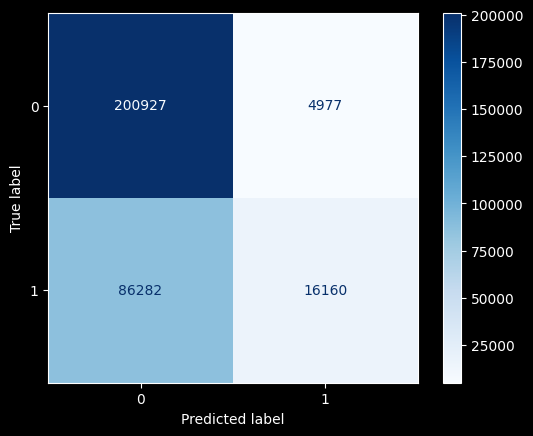

In [83]:
# Confusion matrix
cfm = confusion_matrix(cb_pred, y_test)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

 ### Threshold Tuning / Decile Evaluation

In [84]:
def decile_plot(probability, plot_title, y_test=y_test):
    df_prob = pd.DataFrame({
    'goal_probability': probability,
    'goal_actual': y_test
    })

    df_prob['decile'] = pd.qcut(
        df_prob['goal_probability'],
        10,
        labels=False,
        duplicates='drop'
    )

    # reverse the labels so 0 = highest probability
    df_prob['decile'] = df_prob['decile'].max() - df_prob['decile']

    deciles = (df_prob.groupby('decile').agg(
        shots=('goal_actual', 'count'),
        goals=('goal_actual', 'sum'),
        avg_predicted=('goal_probability', 'mean')
    ))

    deciles['goal_rate'] = deciles['goals'] / deciles['shots']
    baseline = df_prob['goal_actual'].mean()
    deciles['lift'] = deciles['goal_rate'] / baseline

    deciles = deciles.sort_index()

    # Plot lift by decile
    plt.figure(figsize = (10,5))
    plt.subplot(1,2,1)

    plt.plot(deciles.index, deciles['lift'], marker='o', linestyle='dashed')
    for x, y in zip(deciles.index, deciles['lift']):
        plt.text(x, y, f"{y:.2f}", ha='right', va='bottom')
    plt.xticks(deciles.index)
    plt.xlabel('Decile')
    plt.ylabel('Lift')
    plt.title('Lift by Decile')

    # Plot goals by decile
    plt.subplot(1,2,2)
    plt.bar(deciles.index, deciles['goals'])
    plt.xticks(deciles.index)
    plt.xlabel('Decile')
    plt.ylabel('Actual Goals')
    plt.title('Goals by Decile')

    plt.suptitle(plot_title)
    plt.tight_layout()
    plt.show()
    return deciles

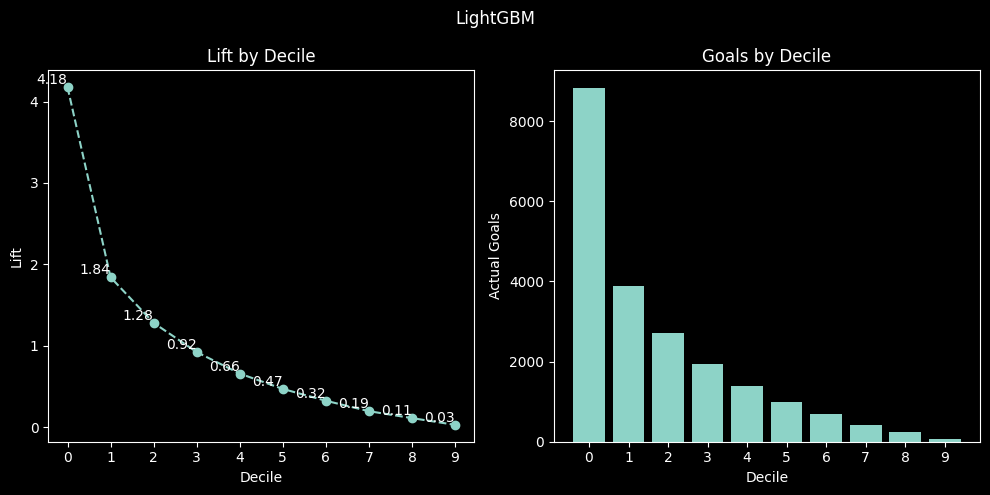

In [85]:
light_deciles = decile_plot(light_proba, 'LightGBM')

In [86]:
light_deciles.sort_values('goals', ascending=False).head(10)

,shots,goals,avg_predicted,goal_rate,lift
decile,,,,,
0,30835,8830,0.790582,0.286363,4.177454
1,30834,3890,0.656779,0.126159,1.840411
2,30835,2706,0.565816,0.087757,1.280203
3,30834,1948,0.481969,0.063177,0.921625
4,30835,1389,0.397542,0.045046,0.657133
5,30834,990,0.307051,0.032107,0.468382
6,30835,683,0.226910,0.022150,0.323126
7,30834,412,0.163014,0.013362,0.194923
8,30835,232,0.111171,0.007524,0.109759


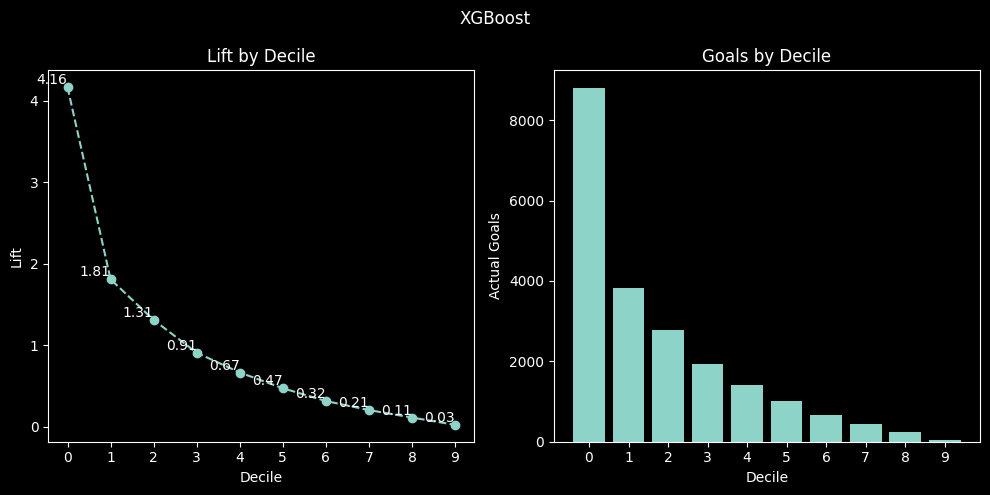

In [87]:
xgb_deciles = decile_plot(xgb_proba, 'XGBoost')

In [88]:
xgb_deciles.sort_values('goals', ascending=False).head(10)

,shots,goals,avg_predicted,goal_rate,lift
decile,,,,,
0,30835,8802,0.798173,0.285455,4.164208
1,30834,3824,0.655981,0.124019,1.809185
2,30835,2772,0.565574,0.089898,1.311427
3,30834,1922,0.484969,0.062334,0.909324
4,30835,1410,0.400721,0.045727,0.667068
5,30834,1002,0.306157,0.032497,0.474059
6,30835,671,0.223043,0.021761,0.317449
7,30834,437,0.155554,0.014173,0.206750
8,30835,243,0.099639,0.007881,0.114963


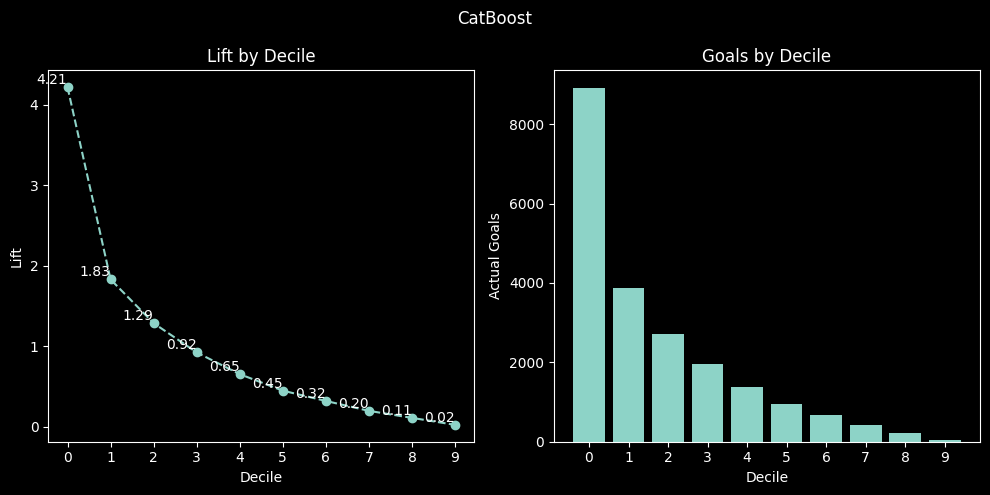

In [89]:
cb_deciles = decile_plot(cb_proba, 'CatBoost')

In [90]:
cb_deciles.sort_values('goals', ascending=False).head(10)

,shots,goals,avg_predicted,goal_rate,lift
decile,,,,,
0,30835,8909,0.789603,0.288925,4.214829
1,30834,3864,0.651395,0.125316,1.828110
2,30835,2717,0.566789,0.088114,1.285407
3,30834,1949,0.484780,0.063209,0.922098
4,30835,1379,0.396555,0.044722,0.652402
5,30834,946,0.306069,0.030680,0.447565
6,30835,676,0.226061,0.021923,0.319814
7,30834,416,0.159718,0.013492,0.196815
8,30835,232,0.101737,0.007524,0.109759


The decile analysis shows that the model is effectively ranking shots by goal probability, with the highest decile capturing 4x more goals than the baseline rate. As we move through the lower deciles, both lift and goal counts decrease, indicating that the model is able to separate higher- and lower-probability scoring chances. CatBoost performs slightly better than XGBoost and LightGBM, though all models show similar overall patterns.

I will run one last grid search with catboost using oversampled data

 ### Oversampled Catboost

In [91]:
ros = RandomOverSampler(random_state=12)
X_ros_cb, y_ros_cb = ros.fit_resample(X_train, y_train)

In [92]:
cat_param_grid = {
    'learning_rate':[0.05, 0.1],
    'depth': [8, 10],
    'l2_leaf_reg': [1,2,3],
}

In [93]:
if os.path.exists('catboost_model_os.cbm'):
    cat_model_os = CatBoostClassifier()
    cat_model_os.load_model('catboost_model_os.cbm')

else:
    cat_model = CatBoostClassifier(
        cat_features=cat_indices,
        random_seed=12,
        verbose=0,
        eval_metric='Logloss',
        task_type='GPU',
        iterations=5000,
        early_stopping_rounds=100
    )

    cat_model.grid_search(
        param_grid=cat_param_grid,
        cv=5,
        X=X_ros_cb,
        y=y_ros_cb,
        partition_random_seed=12
    )

    cat_model_os = cat_model
    cat_model_os.save_model('catboost_model_os.cbm')

In [97]:
if os.path.exists('catboost_model_os.cbm'):
    cat_model_os = CatBoostClassifier()
    cat_model_os.load_model("catboost_model_os.cbm")
else:
    best_params = cat_search_os['params'] # Retrieve the best parameters from grid search
    cat_model_os = CatBoostClassifier(
        cat_features = cat_indices,
        random_seed=12,
        verbose=0,
        **best_params,
        eval_metric='Logloss',
    )
    cat_model_os.fit(X_ros_cb, y_ros_cb)
    cat_model_os.save_model("catboost_model_os.cbm")

In [99]:
cb_os_pred = cat_model_os.predict(X_test)
cb_os_proba = cat_model_os.predict_proba(X_test)[:, 1]

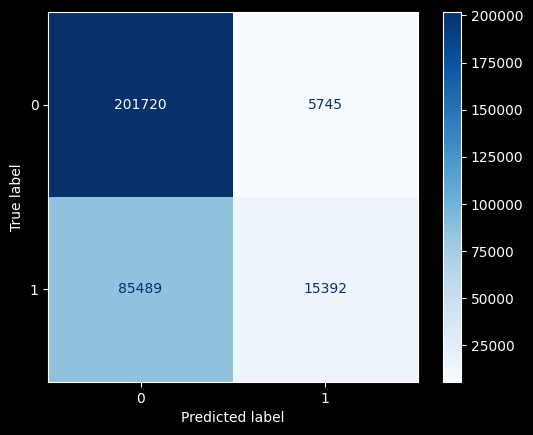

In [104]:
cfm = confusion_matrix(cb_os_pred, y_test)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')

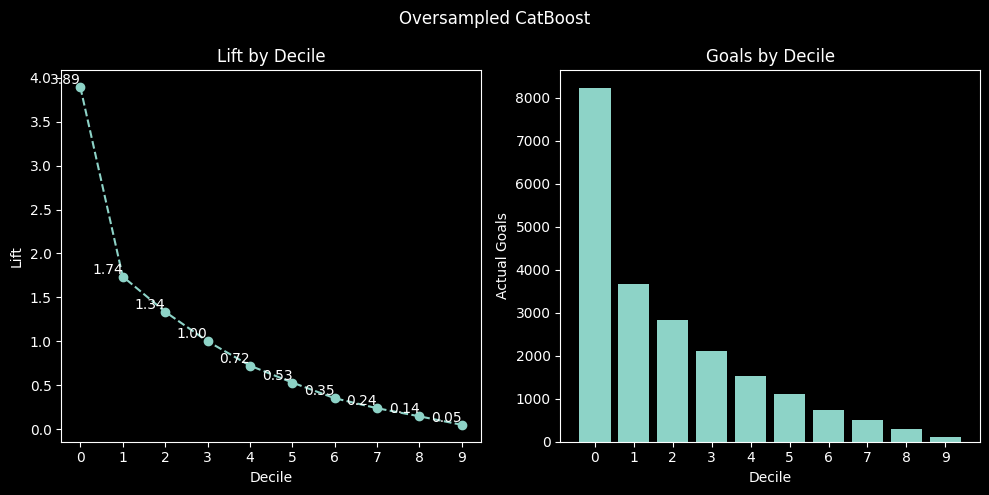

In [101]:
cb_os_deciles = decile_plot(cb_os_proba, 'Oversampled CatBoost')

In [102]:
cb_os_deciles.sort_values('goals', ascending=False).head(10)

,shots,goals,avg_predicted,goal_rate,lift
decile,,,,,
0,30835,8231,0.917532,0.266937,3.894069
1,30834,3672,0.764055,0.119089,1.737272
2,30835,2824,0.616187,0.091584,1.336028
3,30834,2114,0.466823,0.068561,1.000161
4,30835,1527,0.326117,0.049522,0.722420
5,30834,1119,0.206964,0.036291,0.529414
6,30835,742,0.119180,0.024064,0.351039
7,30834,501,0.060615,0.016248,0.237030
8,30835,306,0.024211,0.009924,0.144768


### Conclusion

Oversampling did not lead to a meaningful improvement in model performance, with similar results observed across evaluation metrics and decile-based analysis. This suggests that the model is already effectively handling class imbalance, likely due to the large dataset size and the use of a tree-based method. As a result, oversampling was not used in the final model to avoid unnecessary computational cost. Given the results, the final model will be the undersampled catboost model with the threshold tuned to include deciles 0 through 2 (top 30%).

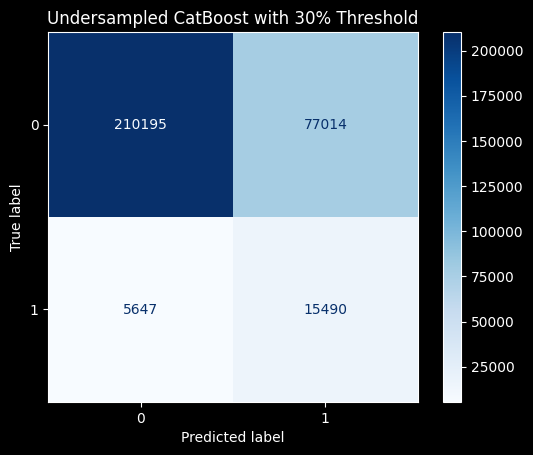

In [123]:
# Confusion Matrix
threshold = np.quantile(cb_proba, 0.70)
y_pred = (cb_proba >= threshold).astype(int)
cfm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cfm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Undersampled CatBoost with 30% Threshold")
plt.show()